# AudioMoth data  

In dit document worden de audio files (WAV) van de audiomoth genalyseerd door te importeren, om te zetten met een FFT en daar een spectogram uit te halen. Hierna kan er gekeken worden naar specifieke buzz frequencies komend uit de literatuur Miller-Struttmann et al., 

This jupyter notebook is based on NeuralNine youtube video "remove background noise with fourier transforms in python" Here ill use short time fourier transform

In [1]:
import os 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import librosa
import scipy.fftpack as fft
import librosa.display
import soundfile as sf

from scipy.signal import medfilt


# Harmonic comb filter

## Load and set parameters

In [12]:
# 1. Load and prep audio
file_path = '../../data/audio_data/original/20260413_113301.WAV'

# Force the sample rate down to 11025 to save processing power
y, sr = librosa.load(file_path, sr=11025)

# STFT Parameters (Balanced for speed and resolution)
n_fft = 1024            # increasing the n_fft will increase resolutin, but it will also decrease time resolution!
hop_length = 256        # increasing the hop_length should bring down computing time if necessary



## create spectrogram and clean noise

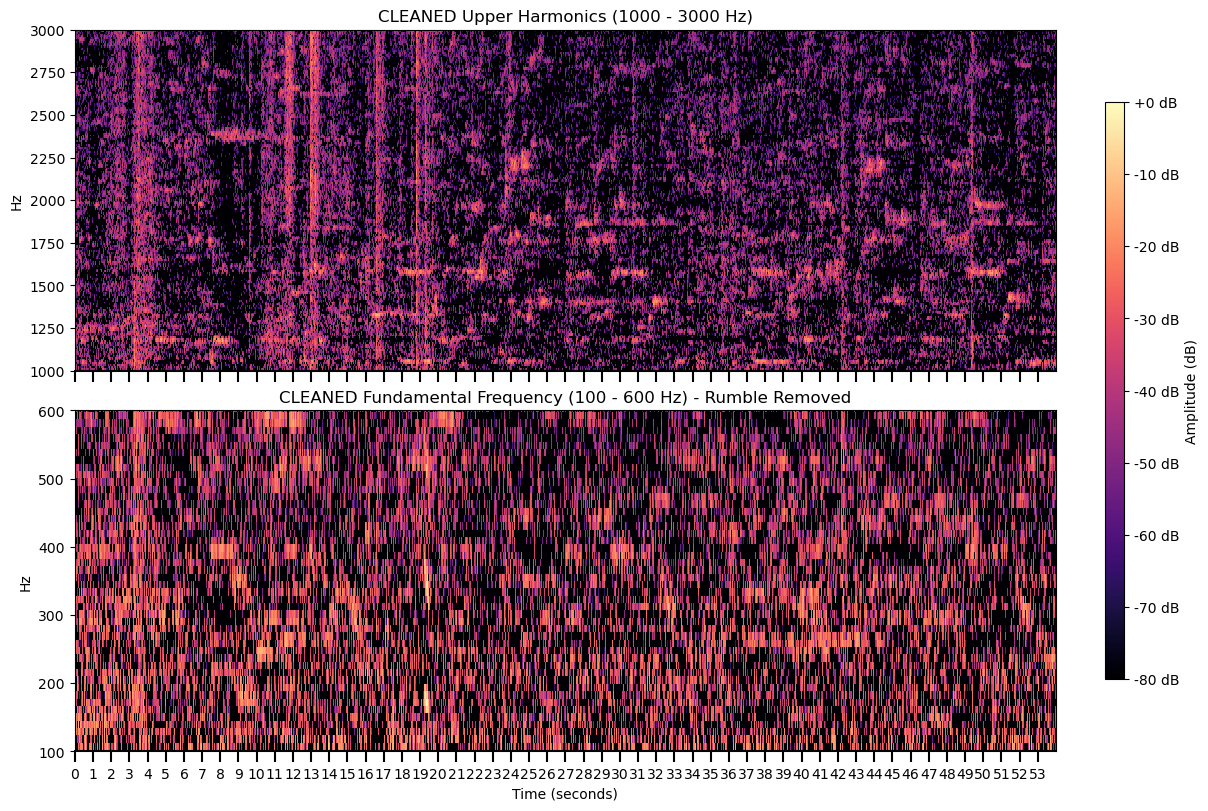

In [13]:
# 2. Create spectrogram & clean noise
# Short -Time Fourier Transform
D = librosa.stft(y, n_fft=n_fft, hop_length=hop_length)
magnitude = np.abs(D)                                   # Get the raw mathematical magnitude (not decibels yet)
freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)     

# Spectral Subtraction (Remove the constant rumble)
noise_profile = np.median(magnitude, axis=1, keepdims=True) # Calculate the median energy for every single frequency row across all time
magnitude_clean = np.maximum(magnitude - noise_profile, 0)  # Subtract the noise profile from the original audio, using np.maximum(...,0) so we dont accidently create negative math errors

# Convert the newly cleaned audio into Decibels for plotting
S_db_clean = librosa.amplitude_to_db(magnitude_clean, ref=np.max)

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), sharex=True, constrained_layout=True)

# Top Plot: The Upper Harmonics
img1 = librosa.display.specshow(S_db_clean, sr=sr, x_axis='time', y_axis='hz', 
                                cmap='magma', n_fft=n_fft, hop_length=hop_length, ax=ax1)
ax1.set_ylim(1000, 3000)
ax1.set_title('CLEANED Upper Harmonics (1000 - 3000 Hz)')
ax1.set_ylabel('Hz')
ax1.set_xlabel('') 

# Bottom Plot: The Fundamental
img2 = librosa.display.specshow(S_db_clean, sr=sr, x_axis='time', y_axis='hz', 
                                cmap='magma', n_fft=n_fft, hop_length=hop_length, ax=ax2)
ax2.set_ylim(100, 600)
ax2.set_title('CLEANED Fundamental Frequency (100 - 600 Hz) - Rumble Removed')
ax2.set_ylabel('Hz')
ax2.set_xlabel('Time (seconds)')

# Formatting the Ruler
for ax in [ax1, ax2]:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
    #ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
    ax.tick_params(axis='x', which='major', length=8, color='black', direction='out', width=1.5)
    #ax.tick_params(axis='x', which='minor', length=4, color='black', direction='out', width=1)
    ax.spines['bottom'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)

fig.colorbar(img1, ax=[ax1, ax2], format='%+2.0f dB', label='Amplitude (dB)', shrink=0.8, aspect=30)


plt.show()

Save image in folder 

In [4]:
# Your existing folder
folder = "results/spectrogram"

# Filename
filename = f"Spectrogram_sr={sr}_nfft={n_fft}_hop={hop_length}.png"

# Full path
file_path = os.path.join(folder, filename)

# Save figure
fig.savefig(file_path, dpi=200)

print(f"Plot saved as {file_path}")

Plot saved as results/spectrogram/Spectrogram_sr=11025_nfft=1024_hop=256.png


## Harmonic comb filter

In [14]:
# 3. THE HARMONIC COMB FILTER (BEE DETECTOR)

f0_min, f0_max = 120, 400  # Biological limits for the engine
num_harmonics = 3          # Look for 2f0, 3f0, 4f0
tolerance = 20             # Allowed offset for messy physics

# Find the array indices that match our 120-400 Hz range
valid_f0_indices = np.where((freqs >= f0_min) & (freqs <= f0_max))[0]

# Arrays to store our results over time
bee_scores = []
f0_tracking = []

# Scan every millisecond
for t in range(S_db_clean.shape[1]):
    frame_data = S_db_clean[:, t] 
    
    # Step A: Find the loudest engine noise in this exact frame
    f0_search_area = frame_data[valid_f0_indices]
    loudest_idx = np.argmax(f0_search_area)
    
    actual_f0_idx = valid_f0_indices[loudest_idx]
    f0_freq = freqs[actual_f0_idx]
    f0_amplitude = frame_data[actual_f0_idx]
    
    # Step B: Cast the harmonic net
    current_score = f0_amplitude 
    
    for h in range(2, num_harmonics + 2): 
        target_freq = f0_freq * h
        search_min = target_freq - tolerance
        search_max = target_freq + tolerance
        
        harmonic_indices = np.where((freqs >= search_min) & (freqs <= search_max))[0]
        
        if len(harmonic_indices) > 0:
            current_score += np.max(frame_data[harmonic_indices])
            
    # Step C: Log it
    bee_scores.append(current_score)
    f0_tracking.append(f0_freq)

bee_scores = np.array(bee_scores)
f0_tracking = np.array(f0_tracking)

print("Audio processed! Mathematical bee scores calculated.")

Audio processed! Mathematical bee scores calculated.


#### PLotting output

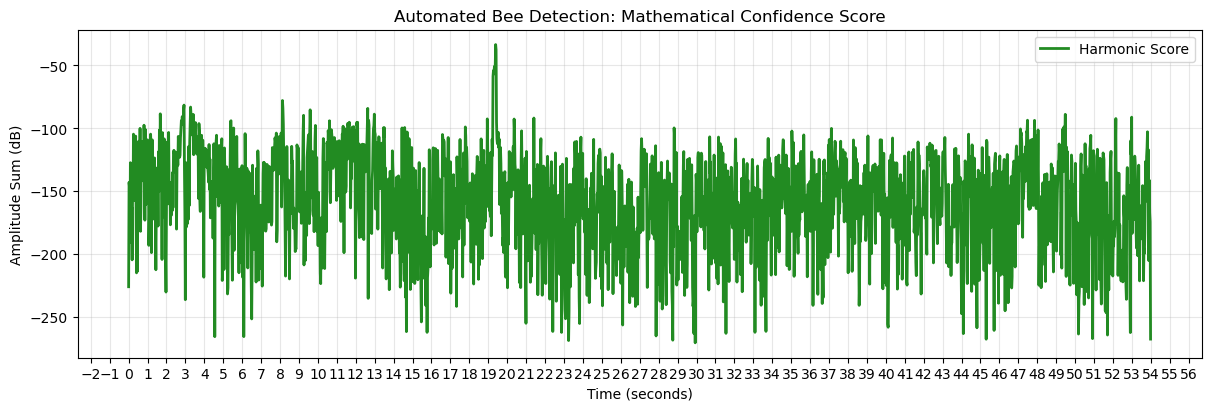

In [15]:
# 1. Convert our frame numbers back into actual seconds for the X-axis
times = librosa.frames_to_time(np.arange(len(bee_scores)), sr=sr, hop_length=hop_length)

# 2. Set up the plot
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)

# Plot the actual scores
ax.plot(times, bee_scores, label='Harmonic Score', color='forestgreen', linewidth=2)

# 3. Let's add a hypothetical "Threshold" line. 
# (You might need to adjust the '150' up or down depending on how high your specific graph spikes!)
#x.axhline(y=threshold_value, color='red', linestyle='--', label='Detection Threshold')

# 4. Make it look professional with labels and our ruler
ax.set_title('Automated Bee Detection: Mathematical Confidence Score')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amplitude Sum (dB)')

ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
#ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.grid(True, alpha=0.3) # Adds a light grid to easily see where the spikes hit
ax.legend()

plt.show()

### First filter out human ladder from bee ladder

The first filter is to look at the harmonic ladder, and works on the principle, that if the pitch (frequency) changes within the window_size and outside of the max_f0_jump it will be deleted. And thus given an silence score of -300 dB. 

<br>
In the plot the threshold is visible, this is the sum of the values from the harmonic ladder that passed the max_jump and window_size.

In [26]:
# Create a copy of our scores to modify
filtered_bee_scores = np.copy(bee_scores)

# Filter Settings
window_size = 2      # Look at 20 frames at a time (about 20 * 0.023 seconds)
max_f0_jump = 10     # If the pitch jumps more than 15 Hz in that window, it's not a bee!
silence_score = -300 # The score we apply to reject the sound

# Slide a window across our tracking data
for i in range(len(f0_tracking) - window_size):
    
    # Grab the small 0.1-second chunk of pitch data
    window_f0 = f0_tracking[i : i + window_size]
    
    # Calculate how much the pitch changed in this tiny window
    pitch_variation = np.max(window_f0) - np.min(window_f0)
    
    # If the pitch is jumping around wildly, it's a voice or music!
    if pitch_variation > max_f0_jump:
        # Override the score in this window to pure silence
        filtered_bee_scores[i : i + window_size] = silence_score

print("First human voice and radio filter applied!")

First human voice and radio filter applied!


PLotting

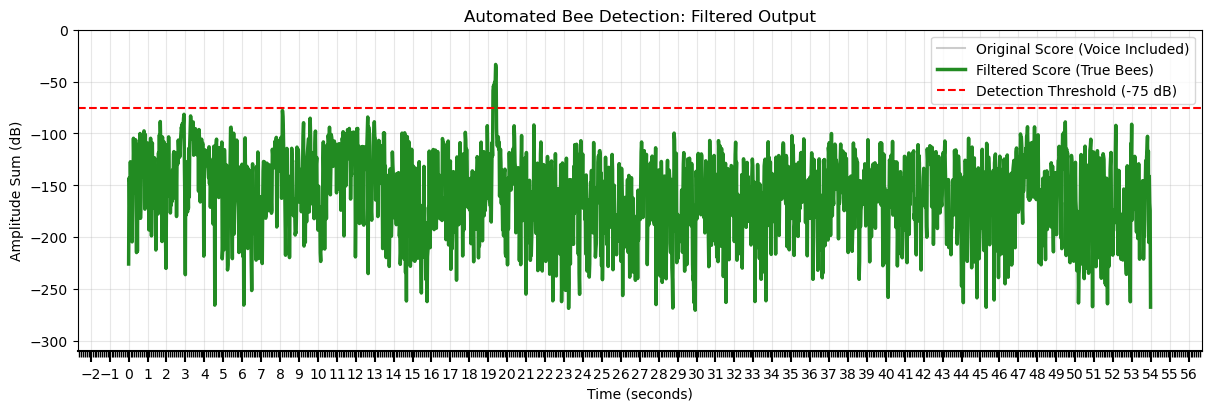

In [39]:


# Set up the plot
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)

# 1. Plot the ORIGINAL scores faintly in the background
ax.plot(times, bee_scores, label='Original Score (Voice Included)', color='gray', alpha=0.4, linewidth=1.5)

# 2. Plot the NEW FILTERED scores clearly on top
ax.plot(times, filtered_bee_scores, label='Filtered Score (True Bees)', color='forestgreen', linewidth=2.5)

# 3. Add the adjusted Threshold line (-100 dB)
threshold_value = -75
ax.axhline(y=threshold_value, color='red', linestyle='--', label='Detection Threshold (' + str(threshold_value) + ' dB)')

# 4. Styling and Labels
ax.set_title('Automated Bee Detection: Filtered Output')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Amplitude Sum (dB)')

# Lock the Y-axis so the dramatic drop to -300 is perfectly visible
ax.set_ylim(-310, 0) 

# The Ruler Timeline
ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.tick_params(axis='x', which='major', length=8, color='black', direction='out', width=1.5)
ax.tick_params(axis='x', which='minor', length=4, color='black', direction='out', width=1)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1.5)

ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.show()

### Second human and radio filter

The first radio filter let false positives through, visible where the spikes come near the detection threshold. This is due to sounds in the greenhouse that dont change pitch, like an twig snapping etc. 

<br>
The second filter will apply a min_time_second function, this function will measure the amount of frames and thus the time a certain spike is above the set detection threshold. In this block, only the output spikes from filter one are looked at. 

In [31]:
# 1. Create a fresh copy of our original scores
filtered_bee_scores = np.copy(bee_scores)

# 2. Filter Settings
min_time_seconds = 0.1  # A spike MUST last this long to be a bee!

# Convert our minimum time limit into a number of frames
# (0.3 seconds / 0.023 seconds per frame = roughly 13 frames)
min_duration_frames = int(min_time_seconds / (hop_length / sr))

# Variables to track our current spike
current_spike_length = 0
spike_start_idx = 0

# 3. Scan the scores frame by frame
for i in range(len(bee_scores)):
    
    # Are we currently above the threshold?
    if bee_scores[i] > threshold_value:
        if current_spike_length == 0:
            spike_start_idx = i  # Mark where the spike started
        current_spike_length += 1
        
    # The moment the score drops back below the threshold
    else:
        # Check if the spike we just finished was too short
        if 0 < current_spike_length < min_duration_frames:
            # It was a voice/noise! Erase it by setting it to pure silence.
            filtered_bee_scores[spike_start_idx : spike_start_idx + current_spike_length] = -300
            
        # Reset the counter for the next spike
        current_spike_length = 0

# (Safety catch in case the audio file ends right in the middle of a spike)
if 0 < current_spike_length < min_duration_frames:
    filtered_bee_scores[spike_start_idx : spike_start_idx + current_spike_length] = -300

print("Duration filter applied! Short noise/voice spikes erased.")

Duration filter applied! Short noise/voice spikes erased.


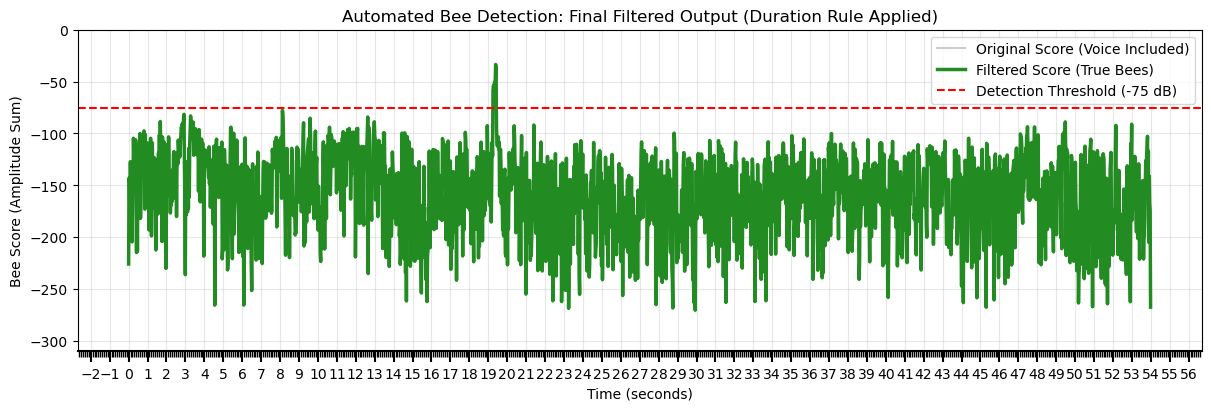

In [37]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)

# 1. Plot the ORIGINAL scores faintly in the background
ax.plot(times, bee_scores, label='Original Score (Voice Included)', color='gray', alpha=0.4, linewidth=1.5)

# 2. Plot the NEW FILTERED scores clearly on top
ax.plot(times, filtered_bee_scores, label='Filtered Score (True Bees)', color='forestgreen', linewidth=2.5)

# 3. Add the adjusted Threshold line (-100 dB)
ax.axhline(y=threshold_value, color='red', linestyle='--', label='Detection Threshold ('+ str(threshold_value) + ' dB)')

# 4. Styling and Labels
ax.set_title('Automated Bee Detection: Final Filtered Output (Duration Rule Applied)')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Bee Score (Amplitude Sum)')

# Lock the Y-axis so the dramatic drop to -300 is perfectly visible
ax.set_ylim(-310, 0) 

# The Ruler Timeline
ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.tick_params(axis='x', which='major', length=8, color='black', direction='out', width=1.5)
ax.tick_params(axis='x', which='minor', length=4, color='black', direction='out', width=1)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1.5)

ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.show()

In [40]:
# See the distribution of your scores
print(f"Max score:    {bee_scores.max():.2f} dB")
print(f"Mean score:   {bee_scores.mean():.2f} dB")
print(f"75th percentile: {np.percentile(bee_scores, 75):.2f} dB")
print(f"90th percentile: {np.percentile(bee_scores, 90):.2f} dB")
print(f"95th percentile: {np.percentile(bee_scores, 95):.2f} dB")

Max score:    -33.51 dB
Mean score:   -158.65 dB
75th percentile: -129.13 dB
90th percentile: -112.84 dB
95th percentile: -105.23 dB


## Double pipeline

In [24]:
# ==========================================
# THE ULTIMATE DOUBLE PIPELINE
# ==========================================

# 1. We copy the raw data exactly ONCE at the very beginning
final_scores = np.copy(bee_scores)

# --- FILTER 1: PITCH STABILITY (The Scalpel) ---
window_size = 5      
max_f0_jump = 15      
silence_score = -300

for i in range(len(f0_tracking) - window_size):
    window_f0 = f0_tracking[i : i + window_size]
    pitch_variation = np.max(window_f0) - np.min(window_f0)
    
    if pitch_variation > max_f0_jump:
        final_scores[i : i + window_size] = silence_score

# --- FILTER 2: MINIMUM DURATION (The Bouncer) ---
# (Notice how we use strict radio settings here, and we scan 'final_scores')
threshold_value = -75
min_time_seconds = 0.7  
min_duration_frames = int(min_time_seconds / (hop_length / sr))

current_spike_length = 0
spike_start_idx = 0

for i in range(len(final_scores)):
    if final_scores[i] > threshold_value:
        if current_spike_length == 0:
            spike_start_idx = i  
        current_spike_length += 1
    else:
        if 0 < current_spike_length < min_duration_frames:
            final_scores[spike_start_idx : spike_start_idx + current_spike_length] = -300
        current_spike_length = 0

# (Safety catch for the end of the file)
if 0 < current_spike_length < min_duration_frames:
    final_scores[spike_start_idx : spike_start_idx + current_spike_length] = -300

print("Pipeline Complete: Pitch and Duration applied in sequence.")

Pipeline Complete: Pitch and Duration applied in sequence.


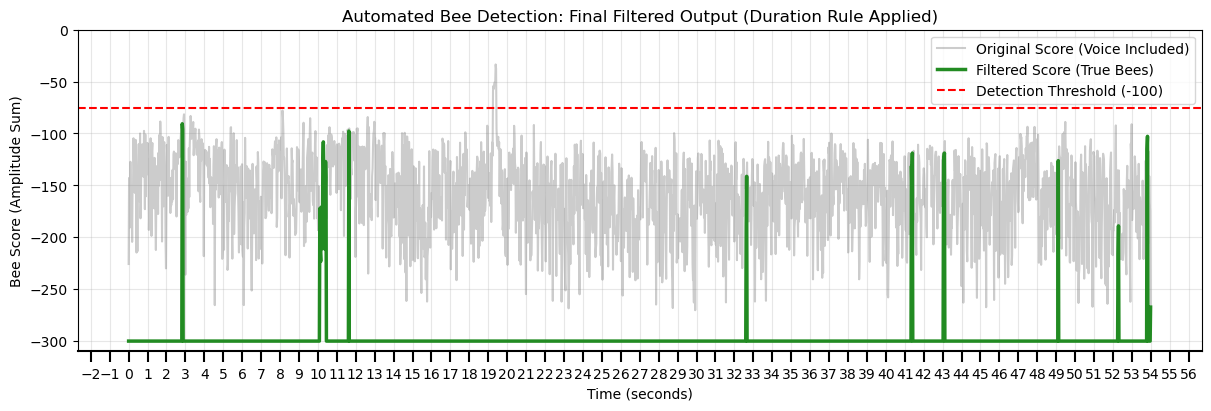

In [25]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Set up the plot
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)

# 1. Plot the ORIGINAL scores faintly in the background
ax.plot(times, bee_scores, label='Original Score (Voice Included)', color='gray', alpha=0.4, linewidth=1.5)

# 2. Plot the NEW FILTERED scores clearly on top
ax.plot(times, final_scores, label='Filtered Score (True Bees)', color='forestgreen', linewidth=2.5)

# 3. Add the adjusted Threshold line (-100 dB)
ax.axhline(y=threshold_value, color='red', linestyle='--', label='Detection Threshold (-100)')

# 4. Styling and Labels
ax.set_title('Automated Bee Detection: Final Filtered Output (Duration Rule Applied)')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Bee Score (Amplitude Sum)')

# Lock the Y-axis so the dramatic drop to -300 is perfectly visible
ax.set_ylim(-310, 0) 

# The Ruler Timeline
ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
#ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.1))
ax.tick_params(axis='x', which='major', length=8, color='black', direction='out', width=1.5)
#ax.tick_params(axis='x', which='minor', length=4, color='black', direction='out', width=1)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1.5)

ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')

plt.show()

# Data cleaning & exploring